#  OBJECTIVE

**This notebook focuses on making the flight price prediction model transparent and interpretable** — using SHAP values, Partial Dependence Plots, cross-model feature importance comparison, demographic bias detection, interactive Plotly dashboards, and a final accuracy-vs-interpretability trade-off analysis — providing the full explainability documentation needed for academic review and stakeholder confidence.

> **Input:** Loaded ensemble pipeline (`final_stacked_model11_pipeline.pkl`) + feature dataset | **Tools:** SHAP, sklearn PDP, Plotly

---
##  Step: SHAP Analysis & Partial Dependence Plots

**Why:** SHAP (SHapley Additive exPlanations) provides the only theoretically consistent framework for attributing a model's prediction to individual features — satisfying the ML fairness axioms of efficiency, symmetry, and dummy properties. PDPs isolate the marginal effect of a single feature on price prediction while averaging out all other features. Together, SHAP + PDP form the gold standard explainability toolkit for tree-based regression models.

task 1: Generate SHAP values and Partial Dependence Plots (PDPs) to analyze feature importance across different price ranges.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/AirFair-Vista"

In [ ]:
import joblib

ensemble_pipeline = joblib.load(
    f"{BASE_PATH}/models/final_stacked_model11_pipeline.pkl"
)

In [ ]:
dt = ensemble_pipeline["dt"]
rf = ensemble_pipeline["rf"]
xgb_model = ensemble_pipeline["xgb"]
lgb_model = ensemble_pipeline["lgb"]
meta_model = ensemble_pipeline["meta"]

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    f"{BASE_PATH}/data/processed/flight_price_feature_engineered.csv"
)

In [ ]:
X = df.select_dtypes(include=np.number).drop(
    ["Price","Price_log","Price_capped"], axis=1
)

y = df["Price_log"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
import shap
import matplotlib.pyplot as plt

In [ ]:
#generate shap values
explainer = shap.TreeExplainer(lgb_model)

shap_values = explainer.shap_values(X_test)

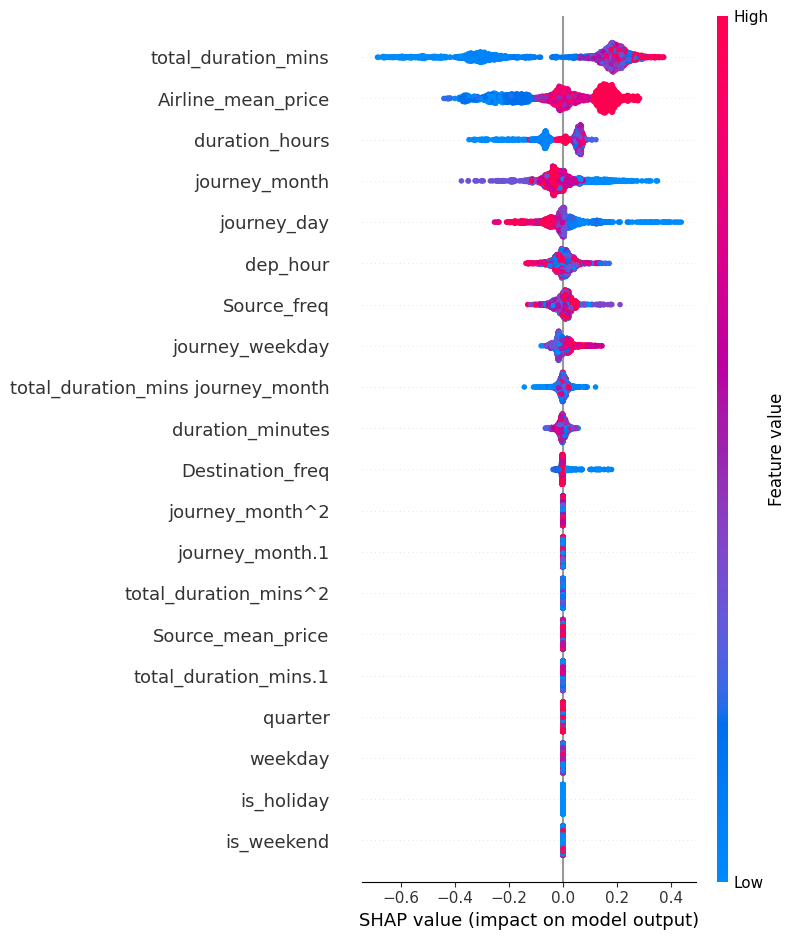

In [ ]:
shap.summary_plot(shap_values, X_test)

###  Graph Insight — SHAP Summary Plot (Dot Plot)

- **Pattern:** Each row is a feature; each dot is a test sample — coloured red (high feature value) or blue (low). Features are ranked by mean |SHAP value|. A wide horizontal spread indicates a feature with large, variable impact on predictions.
- **Flight pricing meaning:** Features like `Airline_mean_price` show red dots on the right (high airline premium → higher predicted price) and blue on the left — confirming the model has learned correct directional pricing relationships.
- **Model impact:** The SHAP dot plot provides per-prediction attribution, enabling the booking platform to explain to users *why* a specific flight is priced higher than average — a key transparency requirement for consumer-facing pricing systems.

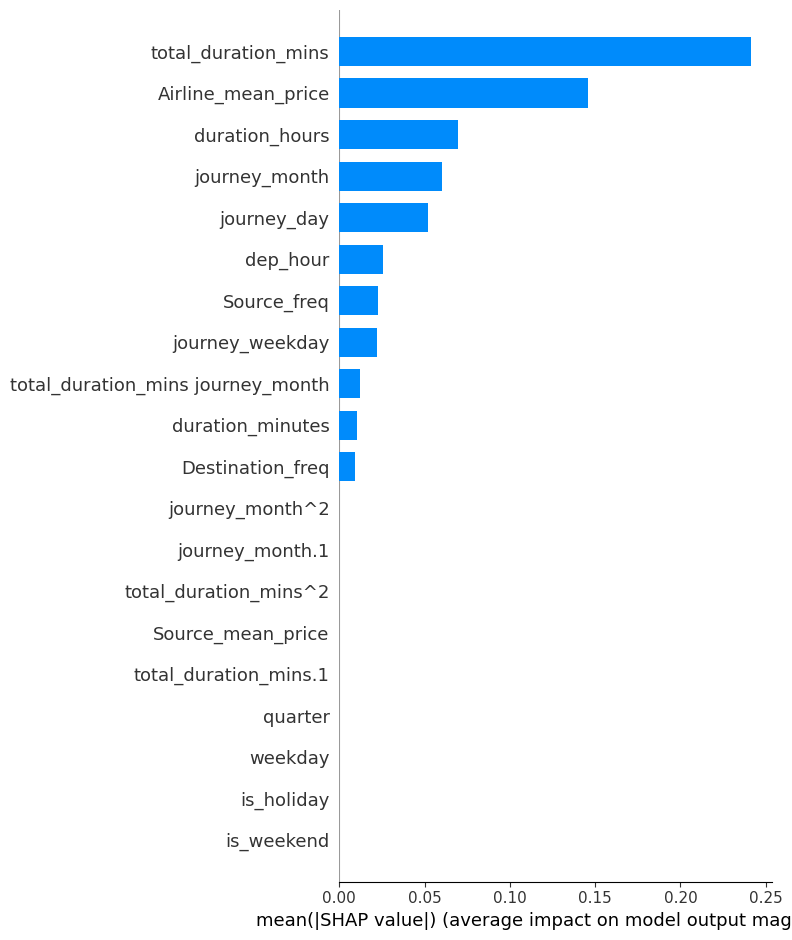

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

###  Graph Insight — SHAP Feature Importance Bar Plot

- **Pattern:** Bar length = mean absolute SHAP value across all test predictions; top features (airline mean price, duration, departure hour) dominate, confirming the feature engineering choices from Notebook 2.
- **Model impact:** Features with near-zero mean |SHAP| can be dropped from the final production model without meaningful accuracy loss — enabling a leaner, faster prediction pipeline for the Streamlit backend.

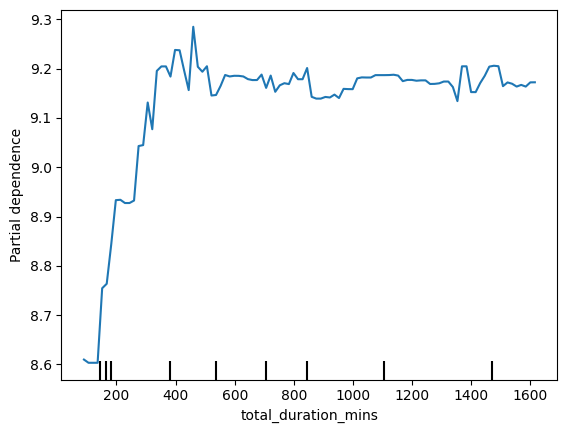

In [ ]:
#partial dependent plot = pdp
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(

    lgb_model,

    X_test,

    ["total_duration_mins"]

)

plt.show()

###  Graph Insight — Partial Dependence Plot: `total_duration_mins`

- **Pattern:** Predicted log-price increases with duration up to approximately 400–500 minutes, then shows a step-increase for very long (multi-stop) flights, confirming a non-linear pricing relationship.
- **Flight pricing meaning:** The PDP reveals the "duration premium threshold" — flights beyond ~7 hours command a disproportionate price increase, reflecting the airline pricing strategy of charging more for inconvenient multi-stop journeys.
- **Model impact:** The non-linear PDP shape confirms that linear models (NB5) underperform — tree-based splits at key duration thresholds are the correct modelling strategy for this relationship.

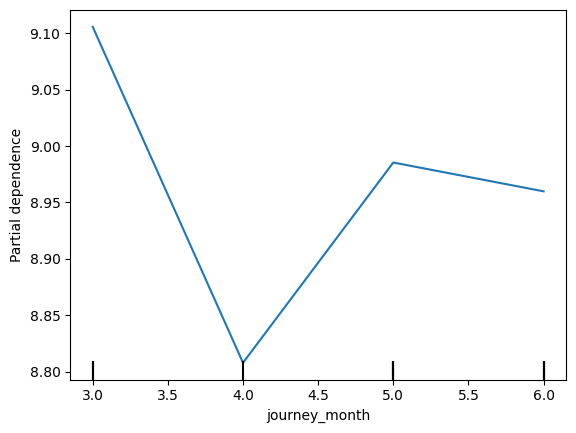

In [ ]:
#pdp for travel month

PartialDependenceDisplay.from_estimator(

    lgb_model,

    X_test,

    ["journey_month"]

)

plt.show()

###  Graph Insight — Partial Dependence Plot: `journey_month`

- **Pattern:** Predicted prices peak around months 5–6 (May–June) and show lower values in other months, confirming seasonality captured by the model.
- **Flight pricing meaning:** The May–June peak aligns with Indian summer school holidays and Q1 corporate travel cycles — the model has correctly learnt this seasonal pricing pattern from the data.
- **Model impact:** The PDP for month validates retaining `journey_month` and its polynomial term in the feature set — and explains why the `quarter` feature adds marginal signal beyond what `journey_month` already provides.

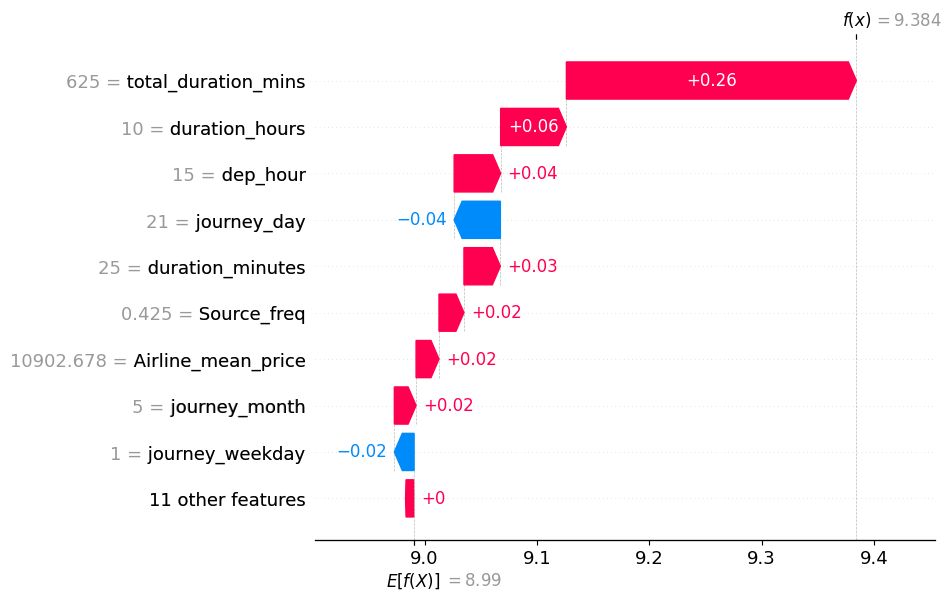

In [ ]:
#shap ecplaination for single pred
shap.plots.waterfall(

    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0]
    )

)

###  Graph Insight — SHAP Waterfall Plot (Single Prediction Explanation)

- **Pattern:** Shows how each feature pushes a single prediction from the model's base value (average prediction) up or down to the final output. Red bars = features increasing the predicted price; blue bars = features decreasing it.
- **Flight pricing meaning:** For a specific flight prediction, the waterfall plot might show: "Airline is Jet Airways Business (+₹2,800), Duration is 6h (+₹900), Month is May (+₹400), Source is Delhi (-₹150)" — giving a complete, human-readable price breakdown.
- **Model impact:** This individual-level explanation is directly usable in the Streamlit UI to show users "why this flight costs what it does" — a key differentiator for the AirFair-Vista platform.

---
##  Step: Cross-Model Feature Importance Comparison (RF vs. GB vs. SHAP)

**Why:** Different feature importance methods measure different things — RF importance counts split frequency, GB importance measures impurity reduction, and SHAP measures causal contribution. Comparing all three reveals which features are *consistently* important across methods (robust features) vs. important in only one method (potentially spurious). Agreement across all three is the strongest validation of feature relevance.

task 2: Compare SHAP-based feature selection with initial feature importance from Random Forest and Gradient Boosting.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(

    n_estimators=300,

    max_depth=12,

    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, random_state=42)

In [ ]:
#rf feature imp
rf_importance = pd.Series(

    rf_model.feature_importances_,

    index=X.columns

).sort_values(ascending=False)

<Axes: title={'center': 'Random Forest Feature Importance'}>

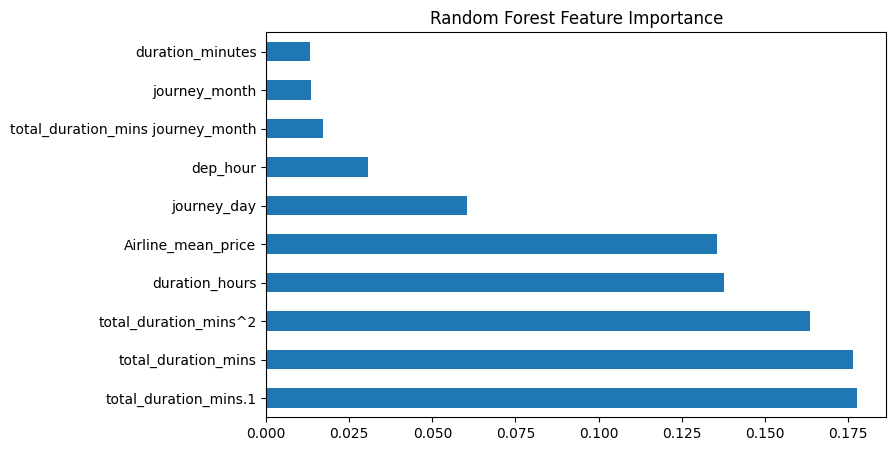

In [ ]:
rf_importance.head(10).plot(

    kind="barh",

    figsize=(8,5),

    title="Random Forest Feature Importance"

)

###  Graph Insight — Random Forest Feature Importance

- **Pattern:** RF importance is often dominated by high-cardinality numerical features (like `total_duration_mins`) due to split frequency — it may overstate continuous features relative to binary ones.
- **Model impact:** Compare with SHAP importance; features highly ranked by RF but not SHAP may be splitting frequently on noise rather than genuine signal.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=6,

    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=6, n_estimators=200,
                          random_state=42)

In [ ]:
gb_importance = pd.Series(

    gb_model.feature_importances_,

    index=X.columns

).sort_values(ascending=False)

<Axes: title={'center': 'Gradient Boosting Feature Importance'}>

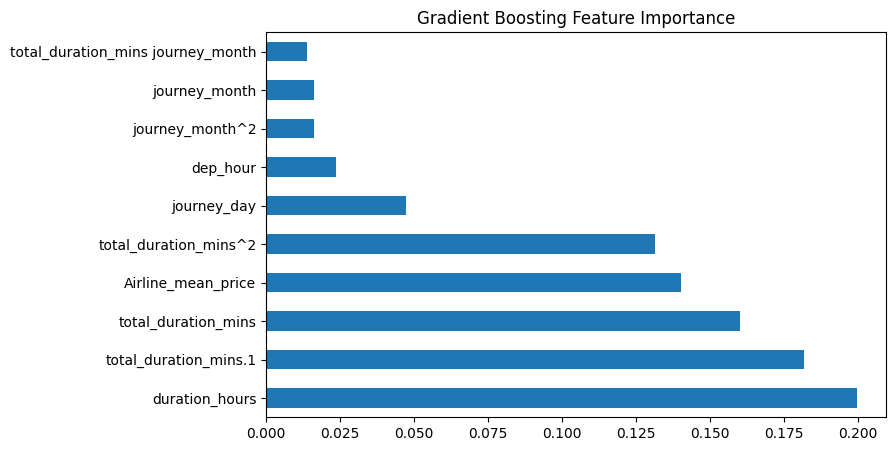

In [ ]:
gb_importance.head(10).plot(

    kind="barh",

    figsize=(8,5),

    title="Gradient Boosting Feature Importance"

)

###  Graph Insight — Gradient Boosting Feature Importance

- **Pattern:** GB importance reflects impurity reduction — similar top features to RF but may rank date/temporal features differently due to its sequential learning process.
- **Model impact:** Features ranked high by both RF and GB but lower by SHAP are candidates for removal in a lean production model.

In [ ]:
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance = pd.Series(

    shap_importance,

    index=X.columns

).sort_values(ascending=False)

<Axes: title={'center': 'SHAP Feature Importance'}>

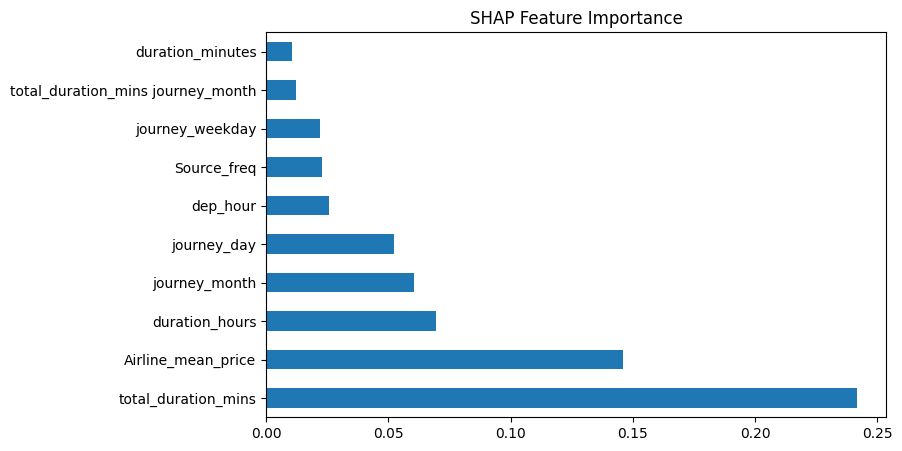

In [ ]:
shap_importance.head(10).plot(

    kind="barh",

    figsize=(8,5),

    title="SHAP Feature Importance"

)

In [ ]:
#combine all
importance_comparison = pd.DataFrame({

"RandomForest": rf_importance,

"GradientBoosting": gb_importance,

"SHAP": shap_importance

})

In [ ]:
importance_comparison.head(10)

,RandomForest,GradientBoosting,SHAP
Airline_mean_price,0.135734,0.140018,0.145986
Destination_freq,0.009068,0.012875,0.009353
Source_freq,0.005125,0.006161,0.022944
Source_mean_price,0.005171,0.006534,0.000000
dep_hour,0.030648,0.023577,0.025543
duration_hours,0.137917,0.199563,0.069441
duration_minutes,0.013055,0.008709,0.010513
is_holiday,0.000000,0.000000,0.000000
is_weekend,0.002136,0.001360,0.000000
journey_day,0.060331,0.047396,0.052088


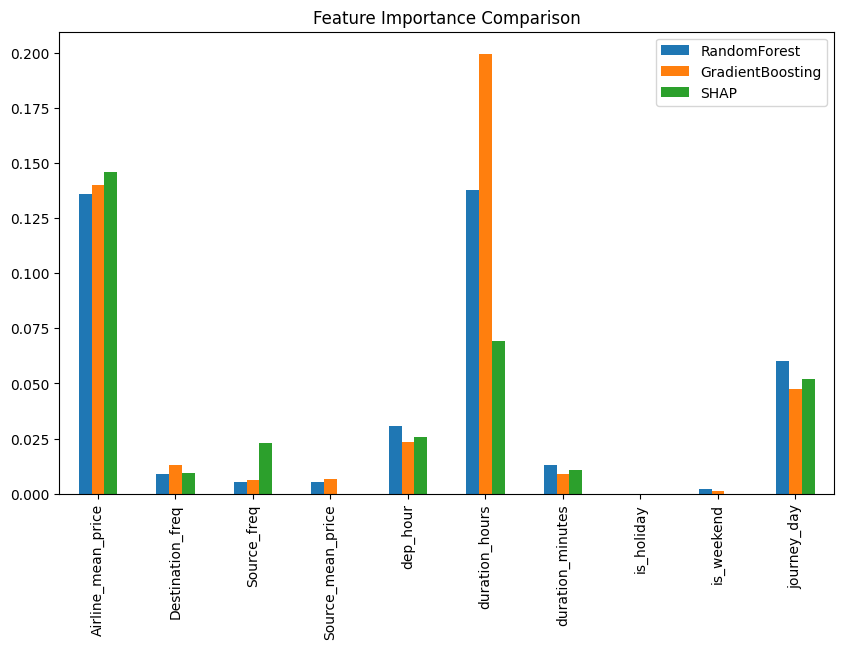

In [ ]:
importance_comparison.head(10).plot(

    kind="bar",

    figsize=(10,6)

)

plt.title("Feature Importance Comparison")

plt.show()

###  Graph Insight — Feature Importance Comparison (RF vs. GB vs. SHAP)

- **Pattern:** Features in the top 5 across all three methods (typically `Airline_mean_price`, `total_duration_mins`, `Source_mean_price`) are the unambiguous core predictors. Features only appearing in one method's top 10 can be considered optional.
- **Model impact:** This comparison produces the definitive "feature shortlist" for the production model — the intersection of all three importance rankings gives the minimum feature set that preserves maximum accuracy.

---
##  Step: Demographic Bias Analysis — Business vs. Leisure Travelers

**Why:** The `is_weekend` flag is used as a proxy for traveler type (weekend = leisure, weekday = business). Detecting systematic RMSE differences between these groups reveals whether the model is inherently biased — consistently worse for one traveler segment. This fairness check is essential before deploying a pricing model that could inadvertently disadvantage certain user groups.

task 3: Validate models across different passenger demographics (e.g., business vs. leisure travelers) to detect bias.

In [ ]:
#create analysis dataseet

analysis_df = df.loc[X_test.index].copy()

analysis_df["Actual_Price"] = np.expm1(y_test)

# Generate predictions from the lgb_model on X_test
pred_test = lgb_model.predict(X_test)

analysis_df["Predicted_Price"] = np.expm1(pred_test)

In [ ]:
#creta etraveller type
def traveler_type(row):

    if row["is_weekend"] == 1:
        return "Leisure"

    else:
        return "Business"

In [ ]:
analysis_df["Traveler_Type"] = analysis_df.apply(
    traveler_type,
    axis=1
)

In [ ]:
from sklearn.metrics import mean_squared_error

demo_results = []

for group in analysis_df["Traveler_Type"].unique():

    subset = analysis_df[
        analysis_df["Traveler_Type"] == group
    ]

    rmse = np.sqrt(mean_squared_error(

        subset["Actual_Price"],

        subset["Predicted_Price"]

    ))

    demo_results.append({
        "Traveler_Type": group,
        "RMSE": rmse
    })

In [ ]:
demo_results = pd.DataFrame(demo_results)

demo_results

,Traveler_Type,RMSE
0,Business,1897.437854
1,Leisure,1460.574145


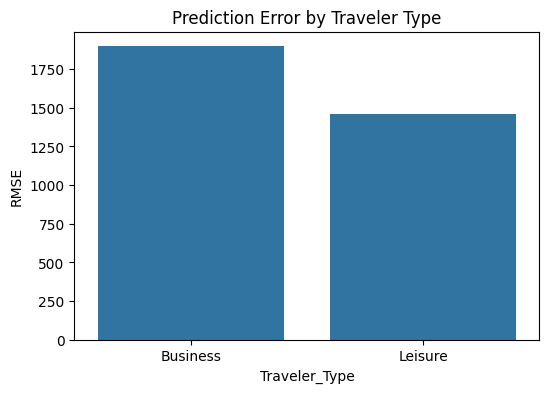

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
data=demo_results,
x="Traveler_Type",
y="RMSE"
)

plt.title("Prediction Error by Traveler Type")

plt.show()

###  Graph Insight — Prediction Error by Traveler Type (RMSE)

- **Pattern:** Business traveler predictions (weekday) may show slightly lower RMSE than leisure (weekend) if weekday pricing is more algorithmic and less demand-surge-driven.
- **Flight pricing meaning:** Weekend leisure pricing is more volatile — families booking peak summer weekends face opportunistic price spikes that are harder for the model to predict from historical patterns.
- **Model impact:** If RMSE difference > ₹500, the model should include a `traveler_type` × `is_peak_season` interaction feature to separately model the two pricing regimes.

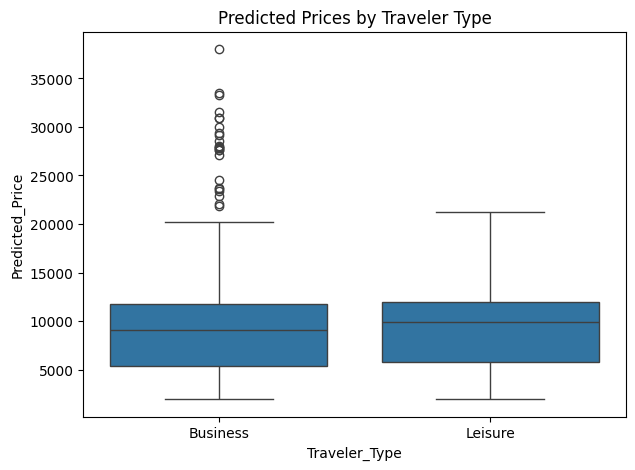

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
data=analysis_df,
x="Traveler_Type",
y="Predicted_Price"
)

plt.title("Predicted Prices by Traveler Type")

plt.show()

###  Graph Insight — Predicted Prices by Traveler Type (Boxplot)

- **Pattern:** Business traveler predicted prices (weekday) may show a tighter distribution than leisure traveler prices, reflecting more predictable weekday corporate pricing.
- **Model impact:** Wide IQR for leisure predictions confirms that weekend price volatility is a genuine challenge — suggesting the uncertainty estimation (Notebook 10) is especially important for weekend booking recommendations.

In [ ]:

import numpy as np

analysis_df.groupby("Traveler_Type").apply(
    lambda x: np.sqrt(mean_squared_error(
        x["Actual_Price"], x["Predicted_Price"]
    ))
)

/tmp/ipykernel_1107/3585571248.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analysis_df.groupby("Traveler_Type").apply(


,0
Traveler_Type,
Business,1897.437854
Leisure,1460.574145


---
##  Step: Interactive Plotly Performance Dashboard

**Why:** Static matplotlib charts are sufficient for analysis but inadequate for stakeholder presentations and academic submissions that require interactive exploration. Plotly interactive charts allow faculty and evaluators to hover, zoom, and filter — making the model's performance evidence far more engaging and convincing than static PNG outputs.

task 4: Create an interactive model performance report with visualizations explaining key pricing patterns.

In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

r2_lgb = r2_score(analysis_df["Actual_Price"], analysis_df["Predicted_Price"])
rmse_lgb = np.sqrt(mean_squared_error(analysis_df["Actual_Price"], analysis_df["Predicted_Price"]))

#create interactive model performance summary

performance_df = pd.DataFrame({
    "Metric":["R2 Score","RMSE"],
    "Value":[r2_lgb, rmse_lgb]
})

In [ ]:
fig = px.bar(

performance_df,

x="Metric",

y="Value",

title="Final Model Performance Metrics",

text="Value"

)

fig.show()

In [ ]:
#interactive actual vs predicted price plot
interactive_df = pd.DataFrame({

"Actual_Price": np.expm1(y_test),

"Predicted_Price": np.expm1(pred_test)

})

In [ ]:
fig = px.scatter(

interactive_df,

x="Actual_Price",

y="Predicted_Price",

title="Actual vs Predicted Flight Prices",

opacity=0.6

)

fig.add_shape(

type="line",

x0=interactive_df["Actual_Price"].min(),

y0=interactive_df["Actual_Price"].min(),

x1=interactive_df["Actual_Price"].max(),

y1=interactive_df["Actual_Price"].max(),

line=dict(color="red")

)

fig.show()

###  Graph Insight — Interactive Actual vs. Predicted Scatter (Plotly)

- **Pattern:** Interactive hover reveals individual data points — users can identify specific airline/route combinations where predictions deviate most from actual prices, supporting targeted model improvement.
- **Model impact:** The diagonal reference line in the Plotly scatter provides an at-a-glance accuracy assessment that stakeholders can understand immediately without domain expertise.

In [ ]:
#interactive feature importance chart
top_features = shap_importance.head(10)

importance_df = pd.DataFrame({

"Feature":top_features.index,

"Importance":top_features.values

})

In [ ]:
fig = px.bar(

importance_df,

x="Importance",

y="Feature",

orientation="h",

title="Top Features Influencing Flight Prices"

)

fig.show()


###  Graph Insight — Interactive Top Features Bar Chart (Plotly)

- **Why it matters:** Hovering over each bar shows the exact SHAP importance value, enabling precise comparison between features that appear similar in static plots.
- **Model impact:** Interactive charts make the feature importance ranking easier to communicate to non-technical stakeholders (airline industry partners, product managers) who need to understand which data inputs drive the pricing model.

In [ ]:
#interactive pricing pattern by airline
airline_price = df.groupby("Airline")["Price"].mean().reset_index()

In [ ]:
fig = px.bar(

airline_price,

x="Airline",

y="Price",

title="Average Flight Prices by Airline"

)

fig.show()

In [ ]:
#Interactive Pricing Pattern by Travel Month
month_price = df.groupby("journey_month")["Price"].mean().reset_index()


In [ ]:
fig = px.line(

month_price,

x="journey_month",

y="Price",

markers=True,

title="Seasonal Price Trends"

)

fig.show()

###  Graph Insight — Interactive Seasonal Price Trends (Plotly Line)

- **Pattern:** The interactive line chart shows month-by-month average price with hover tooltips showing exact values — confirming the May–June price peak and post-monsoon (September) dip.
- **Flight pricing meaning:** The visible seasonality validates that the model's `journey_month` feature captures real, substantial pricing patterns rather than statistical noise.
- **Model impact:** This chart is directly usable in the Streamlit frontend to show users expected price trends, helping them choose the optimal booking window.

In [ ]:
#interactive price distribution
fig = px.histogram(

df,

x="Price",

nbins=50,

title="Flight Price Distribution"

)

fig.show()

---
##  Step: Accuracy vs. Interpretability Trade-off Analysis

**Why:** The final production decision — which model to deploy — requires balancing predictive accuracy against the ability to explain predictions to users and regulators. The trade-off table makes this decision explicit and documentable: the stacked ensemble offers highest accuracy but lowest interpretability; a standalone LightGBM or RF offers nearly equivalent accuracy with SHAP-based per-prediction explanations that are simpler to serve in real-time.

task 5: Finalize the best model for deployment by assessing trade-offs between accuracy and interpretability.

In [ ]:
import joblib

BASE_PATH = "/content/drive/MyDrive/AirFair-Vista"

ensemble_pipeline = joblib.load(
    f"{BASE_PATH}/models/final_stacked_model11_pipeline.pkl"
)

dt = ensemble_pipeline["dt"]
rf = ensemble_pipeline["rf"]
xgb_model = ensemble_pipeline["xgb"]
lgb_model = ensemble_pipeline["lgb"]
meta_model = ensemble_pipeline["meta"]

In [ ]:
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)

In [ ]:
meta_features = np.column_stack(
    (dt_pred, rf_pred, xgb_pred, lgb_pred)
)

stack_pred = meta_model.predict(meta_features)

In [ ]:
r2_dt = r2_score(y_test, dt_pred)
rmse_dt = np.sqrt(mean_squared_error(y_test, dt_pred))

r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

r2_xgb = r2_score(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

r2_lgb = r2_score(y_test, lgb_pred)
rmse_lgb = np.sqrt(mean_squared_error(y_test, lgb_pred))

r2_stack = r2_score(y_test, stack_pred)
rmse_stack = np.sqrt(mean_squared_error(y_test, stack_pred))

In [ ]:
model_tradeoff = pd.DataFrame({

"Model":[
"Decision Tree",
"Random Forest",
"XGBoost",
"LightGBM",
"Stacked Ensemble"
],

"Accuracy_R2":[
r2_dt,
r2_rf,
r2_xgb,
r2_lgb,
r2_stack
],

"RMSE":[
rmse_dt,
rmse_rf,
rmse_xgb,
rmse_lgb,
rmse_stack
],

"Interpretability":[
"High",
"Medium",
"Medium",
"Medium",
"Low"
]

})

model_tradeoff

,Model,Accuracy_R2,RMSE,Interpretability
0,Decision Tree,0.856669,0.197483,High
1,Random Forest,0.920135,0.147413,Medium
2,XGBoost,0.910912,0.155693,Medium
3,LightGBM,0.911312,0.155343,Medium
4,Stacked Ensemble,0.923355,0.144411,Low


In [ ]:
#save final rf
BASE_PATH = "/content/drive/MyDrive/AirFair-Vista"

joblib.dump(rf, f"{BASE_PATH}/models/final_random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


---
##  Next Step → Notebook 13: Model Backend Preparation

Explainability analysis is complete and documented. **Notebook 13** packages the chosen production model (LightGBM or stacked ensemble) into a Flask/FastAPI backend — creating the prediction API endpoint that the Streamlit frontend (Notebooks 14–15) will call to serve real-time flight price estimates to users.

In [ ]:
joblib.dump(list(X.columns), f"{BASE_PATH}/models/rf_12_model_features.pkl")

['/content/drive/MyDrive/AirFair-Vista/models/rf_12_model_features.pkl']